In [6]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import baltic as bt
import re
from collections import defaultdict
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import spearmanr

plt.rcParams['font.family'] = 'Arial'

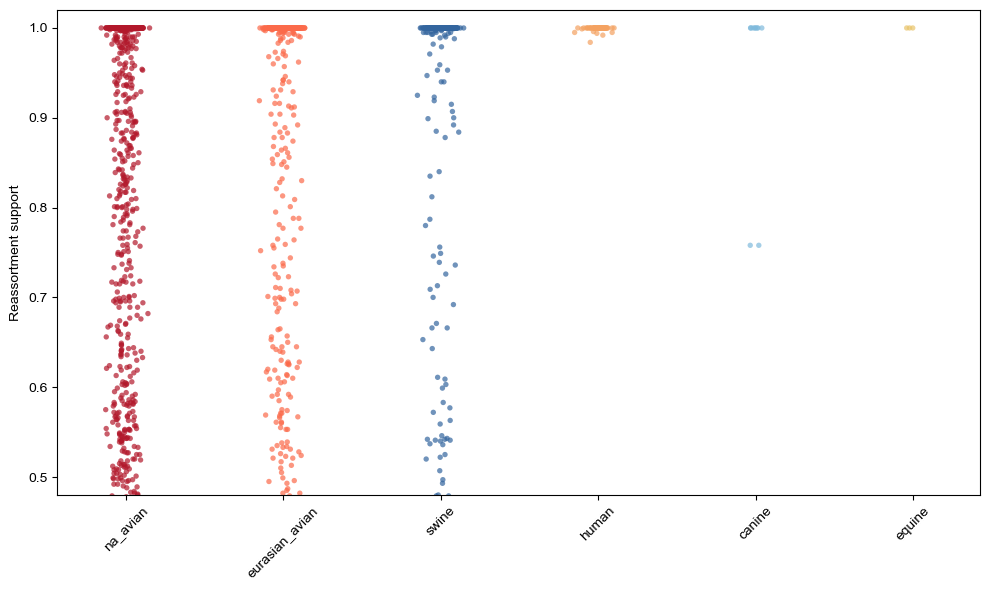

In [7]:
json_folder = "jsons"
clades = ['na_avian', 'eurasian_avian', 'swine', 'human',  'canine', 'equine']

colors = [
    "#b2182b", 
    "#fb6a4a", 
    "#33659e",  
    "#f4a261", 
    "#7fbadc",  
    "#e9c46a", 
]

plot_data = {}
for clade in clades:
    file_path = os.path.join(json_folder, f"{clade}.json")
    with open(file_path, "r") as file:
        data = json.load(file)
    
    true_conf_values = [
        node_data["reassorted_confidence"].get("True", np.nan)
        for node_data in data["nodes"].values()
        if "reassorted_confidence" in node_data
    ]
    plot_data[clade] = [v for v in true_conf_values if not np.isnan(v)]

plt.figure(figsize=(10, 6))
for i, clade in enumerate(clades):
    y_values = plot_data[clade]
    x_values = np.random.normal(i + 1, 0.05, size=len(y_values))  # jitter
    plt.scatter(x_values, y_values, color=colors[i], s=15, alpha=0.7, edgecolors='none')

plt.xticks(range(1, len(clades) + 1), clades, rotation=45)
plt.ylim(0.48, 1.02)
plt.ylabel("Reassortment support")
plt.tight_layout()
plt.savefig("plots/support_per_node.pdf", dpi=300, bbox_inches="tight")
plt.show()




In [8]:
trees_folder = "trees"
plot_data = defaultdict(lambda: defaultdict(dict))

for clade in clades:

    mytree = bt.loadNewick(f'{trees_folder}/{clade}.nwk', absoluteTime= False)
    
    for k in mytree.Objects:
        
        if k.is_leaf():
            plot_data[clade][k.name]["div"] = k.height
            plot_data[clade][k.name]["type"] = 'leaf'
            
        if k.is_node():
            plot_data[clade][k.traits["label"]]["div"] = k.height
            plot_data[clade][k.traits["label"]]["type"] = 'node'
            

    with open(f'jsons/{clade}.json', "r") as file:
        data = json.load(file)
        
    for name, node_data in data["nodes"].items():
        
        plot_data[clade][name]['support'] = node_data["reassorted_confidence"].get("True", np.nan)
        

In [9]:
# smaller height = closer to the root
# y-axis is support
# x-axis is height
# might need to flip

rows = []
for clade, nodes in plot_data.items():
    for name, vals in nodes.items():
        rows.append({
            "clade": clade,
            "name": name,
            "div": vals["div"],
            "type": vals["type"],
            "support": vals["support"]
        })

df = pd.DataFrame(rows)

df


,clade,name,div,type,support
0,na_avian,NODE_1192,0.00100,node,0.000
1,na_avian,NODE_591,0.04208,node,0.117
2,na_avian,NODE_9,0.05264,node,0.088
3,na_avian,A/mallard_duck/ALB/26/1976|1976-08-11,0.06010,leaf,1.000
4,na_avian,NODE_8,0.05385,node,0.076
...,...,...,...,...,...
11487,equine,TS_NODE_214,0.04356,node,0.000
11488,equine,A/equine/Romania/1/1980|1980-01-01,0.04646,leaf,0.000
11489,equine,A/equine/Switzerland/1118/1979|1979-01-01,0.04356,leaf,0.000
11490,equine,A/equine/France/1/1967|1967-01-01,0.04356,leaf,0.000


na_avian 0.02383738837398717 0.24435224978401776
eurasian_avian -0.07378212307322986 0.0018785445049222345
swine -0.052904728156540085 0.0008002002456594003
human 0.00814721152712769 0.7054331896741491
canine -0.1335724852330523 0.0003351539808602996
equine 0.03387793872750454 0.474943012252617


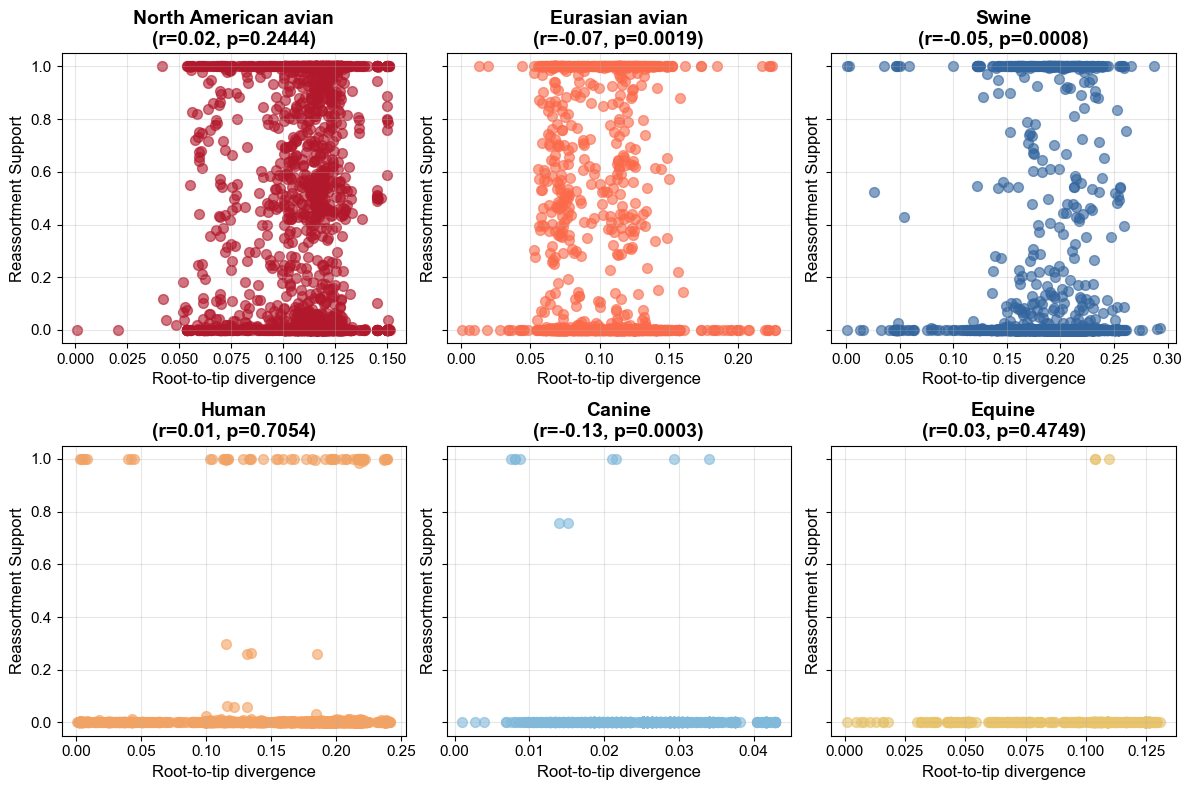

In [10]:
clades = ['na_avian', 'eurasian_avian', 'swine', 'human',  'canine', 'equine']

colors = [
    "#b2182b", 
    "#fb6a4a", 
    "#33659e",  
    "#f4a261", 
    "#7fbadc",  
    "#e9c46a", 
]

clade_labels = {
    'na_avian': 'North American avian',
    'eurasian_avian': 'Eurasian avian',
    'swine': 'Swine',
    'human': 'Human',
    'canine': 'Canine',
    'equine': 'Equine'
}

color_map = dict(zip(clades, colors))

fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.flatten()

for ax, clade in zip(axes, clades):
    subset = df[df["clade"] == clade]
    ax.scatter(subset["div"], subset["support"], alpha=0.6, color=color_map[clade], s=50)
    
    r, p = pearsonr(subset["div"], subset["support"])

    print(clade, r, p)
    
    ax.set_title(f"{clade_labels[clade]}\n(r={r:.2f}, p={p:.4f})", fontsize=14, fontweight='bold')
    ax.set_ylabel("Reassortment Support", fontsize=12)
    ax.set_xlabel("Root-to-tip divergence", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/support_rtt.pdf", dpi=300, bbox_inches="tight")
plt.show()